# visualizer
visulazing and exploring our dataset just the way it is

In [22]:
!for /f "tokens=1* delims=:" %a in ('dir /b "..\dataset\CROHME_training_2011" ^| findstr /n "^"') do @if %a LEQ 10 echo %b

formulaire001-equation001.inkml
formulaire001-equation003.inkml
formulaire001-equation010.inkml
formulaire001-equation011.inkml
formulaire001-equation015.inkml
formulaire001-equation016.inkml
formulaire001-equation023.inkml
formulaire001-equation024.inkml
formulaire001-equation028.inkml
formulaire001-equation030.inkml


In [6]:
import xml.etree.ElementTree as ET

tree = ET.parse("../dataset/CROHME_training_2011/formulaire001-equation001.inkml")
root = tree.getroot()

In [8]:
root

<Element '{http://www.w3.org/2003/InkML}ink' at 0x000002357B0EACF0>

In [9]:
strokes = []
for trace in root.iter("{http://www.w3.org/2003/InkML}trace"):
    pts = []
    for pair in trace.text.strip().split(","):
        x, y = map(float, pair.split())
        pts.append((x, y))
    strokes.append(pts)

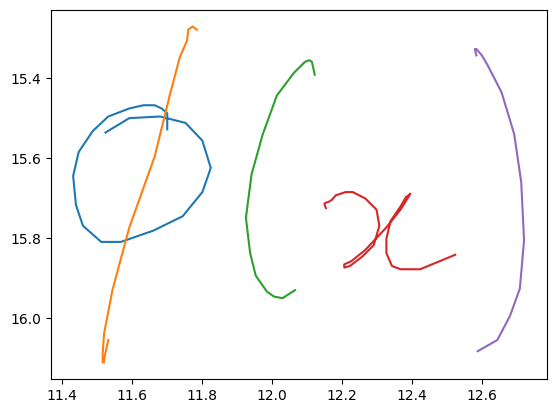

In [10]:
import matplotlib.pyplot as plt

for stroke in strokes:
    xs, ys = zip(*stroke)
    plt.plot(xs, ys)
plt.gca().invert_yaxis()
plt.show()

In [13]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

def inkplot_with_boxes(filename=None, directory="CROHME_training_2011", filepath=None):
    ns = "{http://www.w3.org/2003/InkML}"
    tree = ET.parse(
        f"../dataset/{directory}/{filename}"
    ) if (filename and directory and not filepath) else ET.parse(filepath)

    root = tree.getroot()

    # collect all traces by id
    traces = {}
    for trace in root.iter(f"{ns}trace"):
        tid = trace.attrib["id"]
        raw = trace.text.strip()
        pts = [tuple(map(float, p.split())) for p in raw.split(",")]
        traces[tid] = pts

    # collect symbols (TraceGroups)
    symbols = []
    for tg in root.iter(f"{ns}TraceGroup"):
        # label
        ann = tg.find(f"{ns}annotation")
        if ann is None:
            continue
        label = ann.text.strip()

        # strokes in this symbol
        stroke_ids = [
            tv.attrib["traceDataRef"]
            for tv in tg.findall(f"{ns}traceView")
        ]

        # merge all points
        pts = []
        for sid in stroke_ids:
            pts.extend(traces[sid])

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)

        symbols.append({
            "label": label,
            "bbox": (xmin, ymin, xmax, ymax),
            "stroke_ids": stroke_ids
        })

    # plot
    plt.figure(figsize=(5,5))

    # strokes
    for pts in traces.values():
        xs, ys = zip(*pts)
        plt.plot(xs, ys, linewidth=1, color="black")

    # boxes + labels
    for s in symbols:
        xmin, ymin, xmax, ymax = s["bbox"]
        plt.plot([xmin, xmax, xmax, xmin, xmin],
                 [ymin, ymin, ymax, ymax, ymin],
                 color="red")

        cx = (xmin + xmax) / 2
        cy = (ymin + ymax) / 2
        plt.text(cx, cy, s["label"],
                 ha='center', va='center',
                 fontsize=10, color="blue")

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

    return symbols

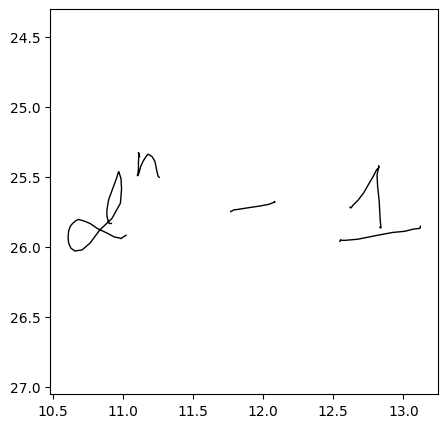

[]

In [8]:
_ = inkplot_with_boxes("formulaire001-equation028.inkml")
_

model architecture we're gonna be using for detection and classification : **[YOLO](https://en.wikipedia.org/wiki/You_Only_Look_Once)**

* why yolo?

because yolo stands for "you only live once", and in this context- it's a super efficient way of doing both these tasks together, in one go. It also ensures the predicitions remain consistent with each other, and improve together when they do.

the yolo architecture is based on CNNs (obv) and are used in the real-world for object detection and related tasks. i wouldn't be suprised if tesla uses these for their CV tasks too!

it's written in: python

our application of this architecture will be fairly simple as compared to the kinds it's actaully designed for. 

and yeah, i would have to read about this architecture extensively before i go on designing my own 👍

#### some more insights

this function that chatgpt wrote apparently tells us which `.inkml` files have a 'truth annotation' in their code. 

In [10]:
import os
import xml.etree.ElementTree as ET

def file_has_symbol_labels(path):
    ns = "{http://www.w3.org/2003/InkML}"
    try:
        root = ET.parse(path).getroot()
    except ET.ParseError:
        return False

    # iterate ALL nested TraceGroups
    for tg in root.iter(f"{ns}traceGroup"):
        ann = tg.find(f"{ns}annotation")
        if ann is None:
            continue
        text = ann.text.strip()
        if text != "Segmentation":
            return True  # this is a real symbol label
    return False

def scan_dir(d):
    files = os.listdir(d)
    good = []
    bad = []
    for fn in files:
        if fn.endswith(".inkml"):
            p = os.path.join(d, fn)
            if file_has_symbol_labels(p):
                good.append(fn)
            else:
                bad.append(fn)
    return good, bad

# run it
base = "../dataset/trainData_2012_part2"
good, bad = scan_dir(base)

print(len(good), "labeled files")
print(len(bad), "unlabeled files")
print("First 10 labeled:", good[:10])

708 labeled files
0 unlabeled files
First 10 labeled: ['algb06.inkml', 'algb09.inkml', 'crohme_f004-eq035.inkml', 'dif_eqn07.inkml', 'dif_eqn11.inkml', 'dif_eqn15.inkml', 'formulaire001-equation000.inkml', 'formulaire001-equation001.inkml', 'formulaire001-equation003.inkml', 'formulaire001-equation010.inkml']


next up:

* training data and processing it!

#### segmenting directories

based off whether they have truth annotation!

* step 1: list all directories

In [2]:
!cd ../dataset/ && dir

 Volume in drive C has no label.
 Volume Serial Number is 5EAB-43CF

 Directory of C:\Users\welcome\Development\Jupyter\math-cnn\dataset

24-11-2025  21:52    <DIR>          .
24-11-2025  22:06    <DIR>          ..
24-11-2025  21:48    <DIR>          CROHME_test_2011
24-11-2025  21:48    <DIR>          CROHME_training_2011
24-11-2025  21:48    <DIR>          MatricesTest2014
24-11-2025  21:48    <DIR>          MatricesTrain2014
24-11-2025  21:52    <DIR>          testData_2012
24-11-2025  21:48    <DIR>          TestINKML_2013
24-11-2025  21:52    <DIR>          trainData_2012_part1
24-11-2025  21:52    <DIR>          trainData_2012_part2
24-11-2025  21:50    <DIR>          TrainINKML_2013
               0 File(s)              0 bytes
              11 Dir(s)  223,575,097,344 bytes free


* step 2: make a record.

| Trainable              | Non-trainable       |
|-----------------------|--------------------|
| TrainINKML_2013       | CROHME_test_2011   |
| CROHME_training_2011  | testData_2012      |
| MatricesTest2014      | TestINKML_2013     |
| MatricesTrain2014     |                    |
| trainData_2012_part1  |                    |
| trainData_2012_part2  |                    |

#### now let's take one file and analyze how it's done

this will take some time to ensure we're all up with it!

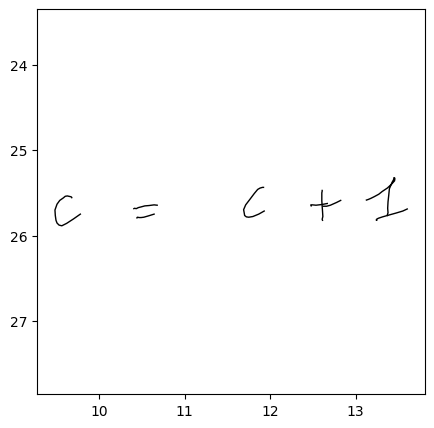

[]

In [14]:
inkplot_with_boxes(filename="formulaire024-equation033.inkml", directory="TrainINKML_2013")

#### next steps:

* preparing training data for our YOLO model.

it needs these two stuff ready to learn upon:

* bounding boxes
* symbols

therefore, our next steps are:

* prepare a processed dataset with files corresponding to their bounding boxes (x & y cooords) and symbols extracted from their metadata we just explored.
* perform train, test split so we're up and running!